<>:76: SyntaxWarning: invalid escape sequence '\o'
<>:76: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_30268\1653270101.py:76: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')


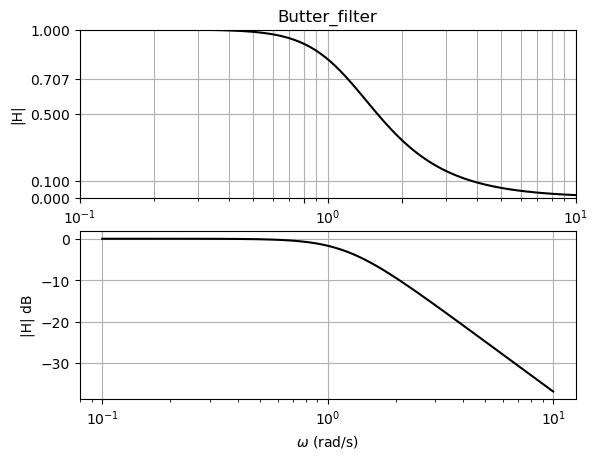

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_30268\1653270101.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[m] = C.dot(x) + D*f[m]


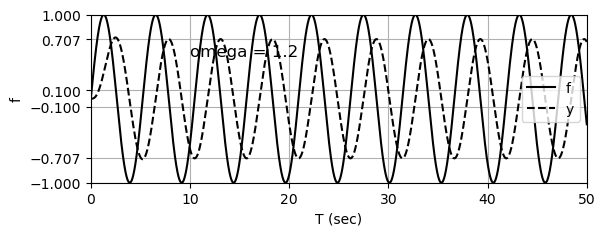

In [13]:
"""Butter_filter.py """

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, log10, sqrt
from control import margin

""" One pole """
n1 = [0,1]
d1 = [1,1]

""" Two poles """
n2 = [0, 0, 1]
d2 = [1, 1.41, 1]

#Scale to wc = a
#For a HPF
a = 1.2
n2 = [0,0,a**2]
d2 = [1,1.41*a,a**2]

""" Three poles """
n3 = [0,0,0,1]
da = [1,1]
db = [1,1,1]
d3 = np.convolve(da,db)

#Scale to wc = a
a = 1000
n3 = [0,0,0,a]
da = [1,a]
db = [1/(a**2),1/a,1]
d3 = np.convolve(da,db)

""" Four poles """
phi1 = 22.5*(pi/180)
phi2 = 67.5*(pi/180)
n4 = [0,0,0,0,1]
da = [1,2*cos(phi1),1]
db = [1,2*cos(phi2),1]
d4 = np.convolve(da,db)

""" Five poles """
phi3 = 36*(pi/180)
phi4 = 72*(pi/180)
n5 = [0,0,0,0,0,1]
dc = [1,2*cos(phi3),1]
dd = [1,2*cos(phi4),1]
de = np.convolve(dc, dd)
df = [1,1]
d5 = np.convolve(de, df)

num = n2
den = d2

system = sig.lti(num,den)
w, Hmag, Hphase = sig.bode(system)


plt.subplot(211)
plt.semilogx(w,10**(0.05*Hmag),'k') # Plot amplitude, not dB.
#plt.plot(w,10**(0.05*Hmag),'k')
#plt.semilogx(w,Hmag,'k')
plt.title('Butter_filter')
plt.axis([0.1, 10, 0, 1])
plt.yticks([0, 0.1, .5, .707, 1])
plt.xticks([.5,1,5])
plt.grid(which='both')
plt.ylabel('|H|')
plt.xticks([.1,.8,1,2,10])

plt.subplot(212)
plt.semilogx(w,Hmag,'k') 
plt.grid()
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('|H| dB')
plt.show()


dt = 0.001
NN = 50000
TT = np.arange(0,NN*dt,dt)
y = np.zeros(NN)
f = np.zeros(NN)

A,B,C,D = sig.tf2ss(num,den)
x = np.zeros(np.shape(B))

""" The sinusodal input """
omega = 1.2
for n in range(NN):
    f[n] = sin(omega*n*dt)

plt.subplot(211)
plt.plot(TT,f,'k', label='f')
plt.axis([0, NN*dt,-1,1])
plt.grid()
plt.ylabel('f')

for m in range(NN):
    x = x + dt*A.dot(x) + dt*B*f[m]
    y[m] = C.dot(x) + D*f[m]

plt.plot(TT,y,'k--', label='y')
plt.yticks([-1, -.707, -.1, .1,.707, 1 ])
plt.text(10,.5,'omega = {}'.format(round(omega,1)),fontsize=12)
plt.xlabel('T (sec)')
plt.legend()
plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\o'
<>:46: SyntaxWarning: invalid escape sequence '\o'
<>:23: SyntaxWarning: invalid escape sequence '\o'
<>:46: SyntaxWarning: invalid escape sequence '\o'
C:\Users\gjsta\AppData\Local\Temp\ipykernel_68988\1125075995.py:23: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')
C:\Users\gjsta\AppData\Local\Temp\ipykernel_68988\1125075995.py:46: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')


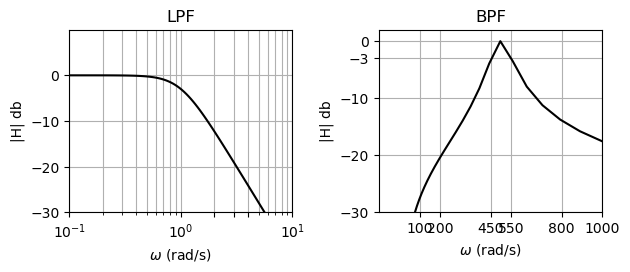

In [4]:
""" Low Pass Filter """

n2 = [0, 0, 1]
d2 = [1, 1.41, 1]

num = n2
den = d2

w = np.linspace(0.1,100,1000)
system = sig.lti(num,den)
w, Hmag, Hphase = sig.bode(system)
gm, pm, wg, wp = margin(Hmag,Hphase,w)

plt.rcParams['font.size']=10
plt.subplot(221)
plt.semilogx(w,Hmag,'k')
plt.title('LPF')
plt.axis([0.1, 10, -30, 10])
plt.yticks([-30, -20, -10, 0])
plt.xticks([.1,1,2,3,4,10])
plt.grid(which='both')
plt.ylabel('|H| db')
plt.xlabel('$\omega$ (rad/s)')

""" Band Pass Filter """

n2 = [0,100,0]
d2 = [1,100,2.5e5]

num = n2
den = d2

w = np.linspace(0.1,100,1000)
system = sig.lti(num,den)
w, Hmag, Hphase = sig.bode(system)
gm, pm, wg, wp = margin(Hmag,Hphase,w)

plt.subplot(222)
plt.plot(w,Hmag,'k')
plt.title('BPF')
plt.axis([-100,1000,-30,2])
plt.yticks([-30, -20, -10, -3, 0])
plt.xticks([100,200,450,550,800,1000])
plt.grid(which='both')
plt.ylabel('|H| db')
plt.xlabel('$\omega$ (rad/s)')
plt.tight_layout()

<>:29: SyntaxWarning: invalid escape sequence '\o'
<>:29: SyntaxWarning: invalid escape sequence '\o'
C:\Users\gjsta\AppData\Local\Temp\ipykernel_68988\3897308172.py:29: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')


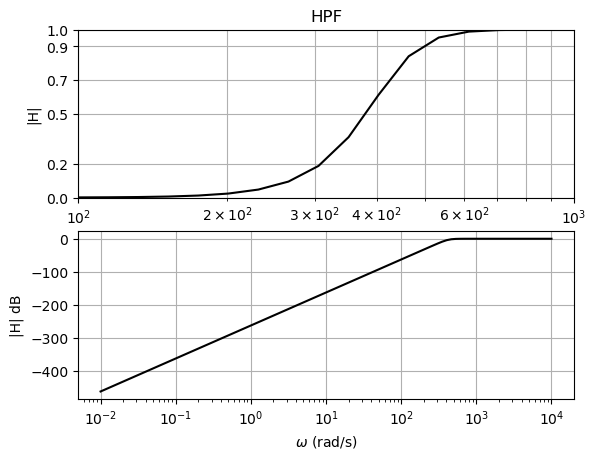

In [9]:
""" High Pass Filter """

a = 425
phi1 = 36*(pi/180)
phi2 = 72*(pi/180)
da = [1,a]
db = [1,a*2*cos(phi1),a**2]
dc = [1,a*2*cos(phi2),a**2]
dbc = np.convolve(db,dc)
d5 = np.convolve(da,dbc)
n5 = [1,0,0,0,0,0]
num = n5
den = d5

system = sig.lti(num,den)
w, Hmag, Hphase = sig.bode(system)

plt.subplot(211)
plt.semilogx(w,10**(0.05*Hmag),'k')
plt.title('HPF')
plt.axis([100, 1000, 0, 1])
plt.yticks([0, 0.2, 0.5, 0.7, 0.9, 1])
plt.grid(which='both')
plt.ylabel('|H|')

plt.subplot(212)
plt.semilogx(w,Hmag,'k')
plt.grid()
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('|H| dB')
plt.show()